In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "figure.figsize": (5, 4),
})


In [74]:
T = 0.001
data_dir = f"T_{T}"
csv_file = os.path.join(data_dir, "pairscatter_points.csv")
df = pd.read_csv(csv_file)
df.head()


,conf_id,sweep,site_idx,re,im
0,conf_1,1,1,0.008228,0.012742
1,conf_1,1,2,0.000041,0.008784
2,conf_1,1,3,0.013684,-0.006534
3,conf_1,1,4,-0.003061,-0.001983
4,conf_1,1,5,0.006829,0.002926


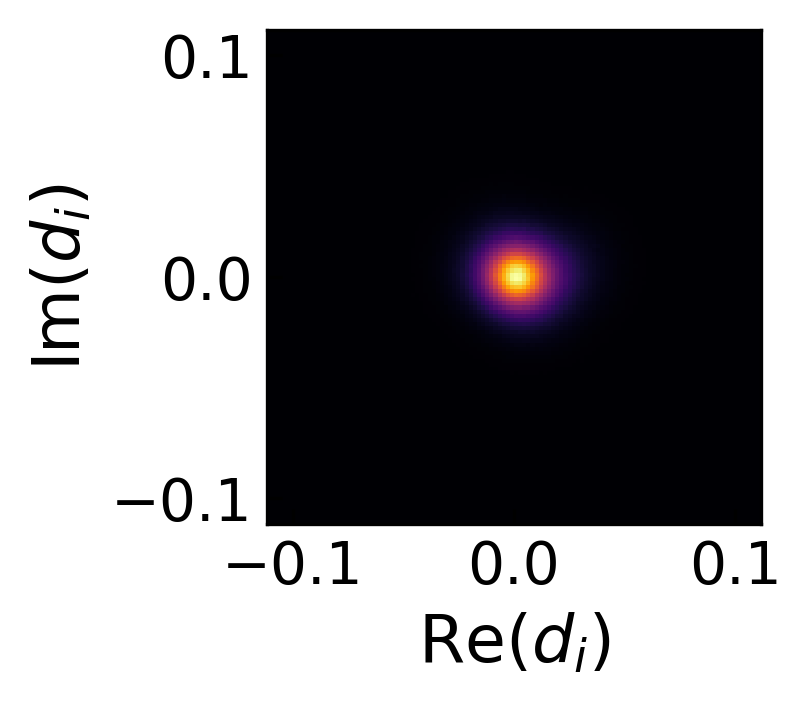

In [75]:
# 2D histogram in complex plane
re = df["re"].to_numpy()
im = df["im"].to_numpy()

n_bins = 120
max_abs = np.max(np.abs(np.concatenate([re, im])))
edges = np.linspace(-max_abs, max_abs, n_bins + 1)

H, xedges, yedges = np.histogram2d(re, im, bins=[edges, edges])

plt.figure(figsize=(3, 3), dpi=300)
pcm = plt.pcolormesh(xedges, yedges, H.T, shading="auto", cmap="inferno")
# cbar = plt.colorbar(pcm)
# cbar.set_label("count")
plt.xlabel(r"Re$(d_i)$")
plt.ylabel(r"Im$(d_i)$")
plt.axis("scaled")
plt.tight_layout()
plt.show()


In [76]:
# # Re(d) distribution
# bins = np.linspace(-max_abs, max_abs, n_bins + 1)
# hist, edges = np.histogram(re, bins=bins, density=True)
# centers = 0.5 * (edges[:-1] + edges[1:])

# plt.figure(figsize=(5, 4), dpi=300)
# plt.plot(centers, hist, "k-")
# plt.xlabel(r"Re$(d_i)$")
# plt.ylabel("Probability density")
# plt.tight_layout()
# plt.show()

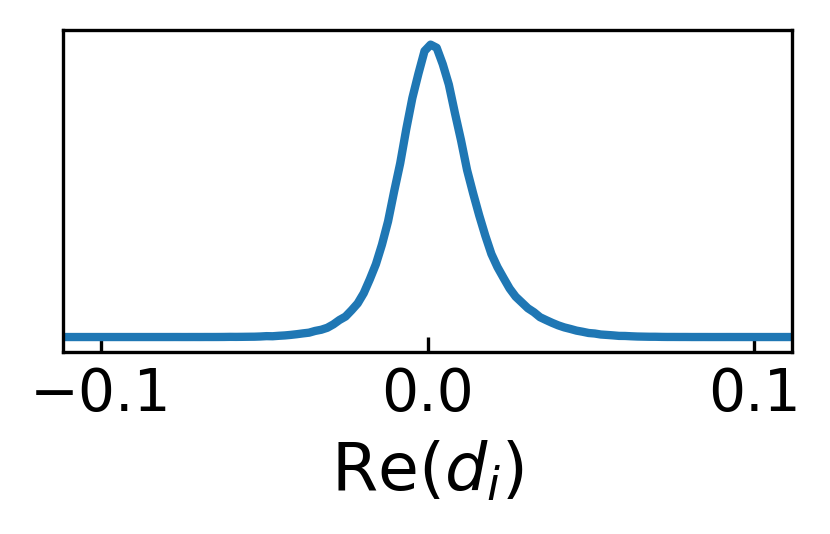

In [77]:
# 1. 计算每个 bin 的中心点坐标
# xedges 和 yedges 是边缘，中心点数量比边缘少 1
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2

# 2. 找到 y_centers 中最接近 0 的索引
# argmin() 会返回绝对值最小处的索引
zero_im_idx = np.abs(y_centers - 0).argmin()

# 3. 从矩阵 H 中提取截面数据
# H 的形状通常是 (nx, ny)，即 (re_bins, im_bins)
# 所以我们需要固定第二个维度 (im)，取所有的第一个维度 (re)
# 注意：np.histogram2d 返回的是 H[x, y]，不用转置直接取列即可
slice_curve = H[:, zero_im_idx]

# 4. 绘制截面图
plt.figure(figsize=(3,2), dpi=300)
plt.plot(x_centers, slice_curve, label=r'Im $\approx$ 0')
plt.xlabel(r"Re$(d_i)$")
# plt.ylabel("Count")
plt.yticks([])
plt.xlim(-max_abs, max_abs)
plt.tight_layout()
plt.show()

In [78]:
# Animation: histogram evolution over sweep
import matplotlib.animation as animation
from IPython.display import display
import matplotlib.patches as patches  # 1. 引入 patches

mode = 'per_sweep'  # 'cumulative' or 'per_sweep'
max_frames = 100
conf_id = 'conf_1'  # e.g. 'conf_1', or None for all

if conf_id is None:
    df_anim = df
else:
    df_anim = df[df['conf_id'] == conf_id]
    if df_anim.empty:
        raise ValueError(f'No data for conf_id={conf_id}')

sweeps = np.sort(df_anim['sweep'].unique())
if len(sweeps) > max_frames:
    idx = np.linspace(0, len(sweeps) - 1, max_frames).astype(int)
    frame_sweeps = sweeps[idx]
else:
    frame_sweeps = sweeps

max_abs = np.max(np.abs(np.concatenate([df_anim['re'].to_numpy(), df_anim['im'].to_numpy()])))
edges = np.linspace(-max_abs, max_abs, n_bins + 1)
extent = [edges[0], edges[-1], edges[0], edges[-1]]

def calc_hist(sweep_val):
    if mode == 'cumulative':
        sub = df_anim[df_anim['sweep'] <= sweep_val]
    else:
        sub = df_anim[df_anim['sweep'] == sweep_val]
    H, _, _ = np.histogram2d(sub['re'], sub['im'], bins=[edges, edges])
    return H

global_max_count = 0
for s in frame_sweeps:
    temp_H = calc_hist(s)
    current_max = temp_H.max()
    if current_max > global_max_count:
        global_max_count = current_max

fig, ax = plt.subplots(figsize=(3, 3), dpi=300)
H0 = calc_hist(frame_sweeps[0])
im = ax.imshow(H0.T, origin='lower', extent=extent, cmap='inferno', aspect='equal')
im.set_clim(vmin=0, vmax=global_max_count if global_max_count > 0 else 1)
# cbar = plt.colorbar(im, ax=ax)
# cbar.set_label('count')
plt.xlabel(r"Re$(d_i)$")
plt.ylabel(r"Im$(d_i)$")
pbar = patches.Rectangle((0, 1.02), 0, 0.04, transform=ax.transAxes, 
                         facecolor='limegreen', edgecolor='none', clip_on=False)
ax.add_patch(pbar)
plt.tight_layout()

def update(sweep_val):
    H = calc_hist(sweep_val)
    im.set_data(H.T)
    current_idx = np.where(frame_sweeps == sweep_val)[0][0]
    total_frames = len(frame_sweeps)
    progress = (current_idx + 1) / total_frames
    pbar.set_width(progress)
    return [im, pbar]

ani = animation.FuncAnimation(fig, update, frames=frame_sweeps, interval=200, blit=False)

out_gif = os.path.join(data_dir, f"pairscatter_hist_{conf_id if conf_id else 'all'}.gif")
try:
    ani.save(out_gif, writer=animation.PillowWriter(fps=24))
    print(f'Saved: {out_gif}')
except Exception as e:
    print(f'GIF save failed: {e}')

display(ani)
plt.close(fig)

Saved: T_0.001/pairscatter_hist_conf_1.gif


In [83]:
df_avg = (
    df
    .groupby(['conf_id', 'site_idx'], as_index=False)
    .agg(
        re_mean=('re', 'mean'),
        re_std =('re', 'std'),
        im_mean=('im', 'mean'),
        im_std =('im', 'std'),
        n_sweep=('re', 'count')
    )
)

df_avg['re_err'] = df_avg['re_std'] / np.sqrt(df_avg['n_sweep'])
df_avg['im_err'] = df_avg['im_std'] / np.sqrt(df_avg['n_sweep'])

df_avg.head()


,conf_id,site_idx,re_mean,re_std,im_mean,im_std,n_sweep,re_err,im_err
0,conf_1,1,0.002313,0.008382,0.002343,0.008719,500,0.000375,0.000390
1,conf_1,2,0.002050,0.007685,0.000554,0.008881,500,0.000344,0.000397
2,conf_1,3,0.002221,0.009411,0.001874,0.010459,500,0.000421,0.000468
3,conf_1,4,0.003532,0.009784,0.002949,0.011424,500,0.000438,0.000511
4,conf_1,5,0.002708,0.008545,0.002004,0.009605,500,0.000382,0.000430


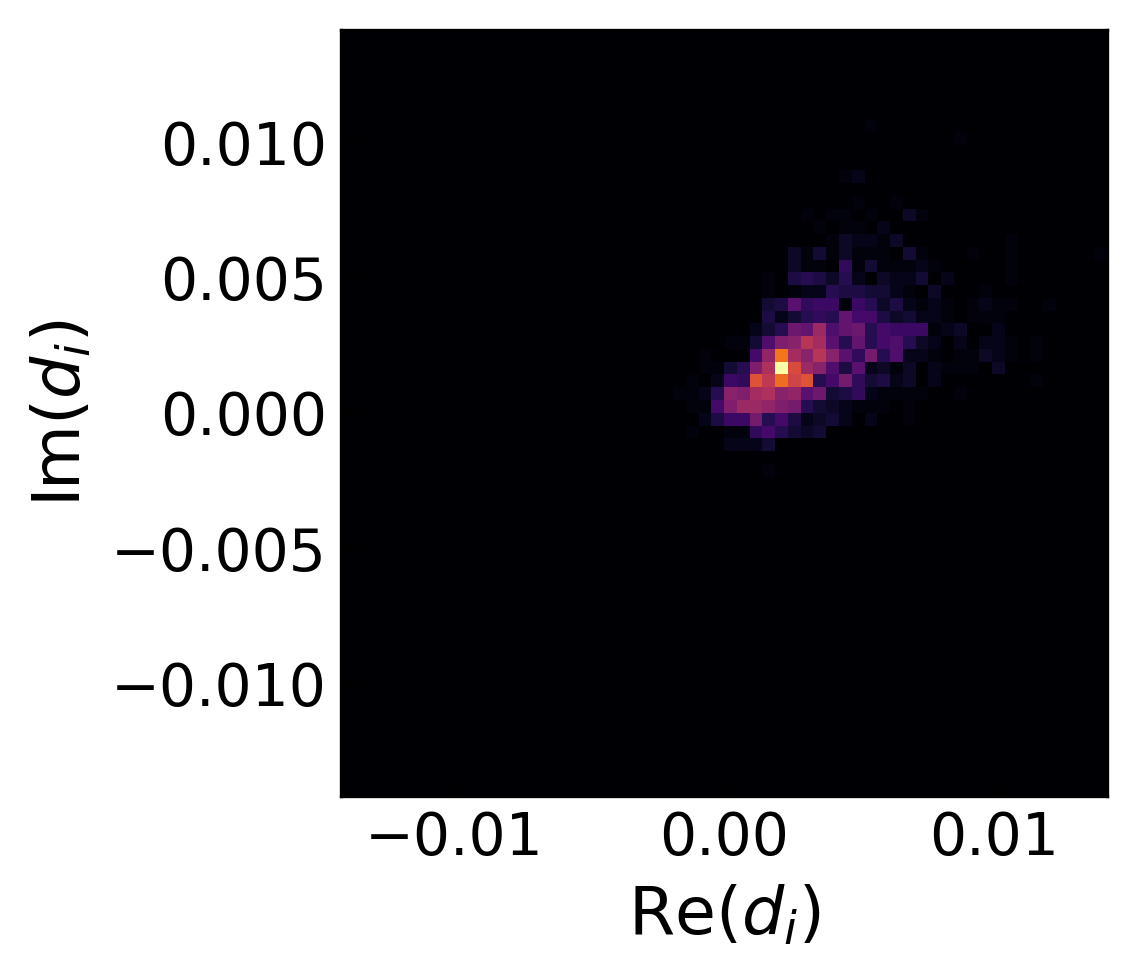

In [87]:
# 2D histogram in complex plane
re = df_avg[df_avg['conf_id']==conf_id]["re_mean"].to_numpy()
im = df_avg[df_avg['conf_id']==conf_id]["im_mean"].to_numpy()

n_bins = 60
max_abs = np.max(np.abs(np.concatenate([re, im])))
edges = np.linspace(-max_abs, max_abs, n_bins + 1)

H, xedges, yedges = np.histogram2d(re, im, bins=[edges, edges])

plt.figure(figsize=(4, 4), dpi=300)
pcm = plt.pcolormesh(xedges, yedges, H.T, shading="auto", cmap="inferno")
# cbar = plt.colorbar(pcm)
# cbar.set_label("count")
plt.xlabel(r"Re$(d_i)$")
plt.ylabel(r"Im$(d_i)$")
plt.axis("scaled")
plt.tight_layout()
plt.show()


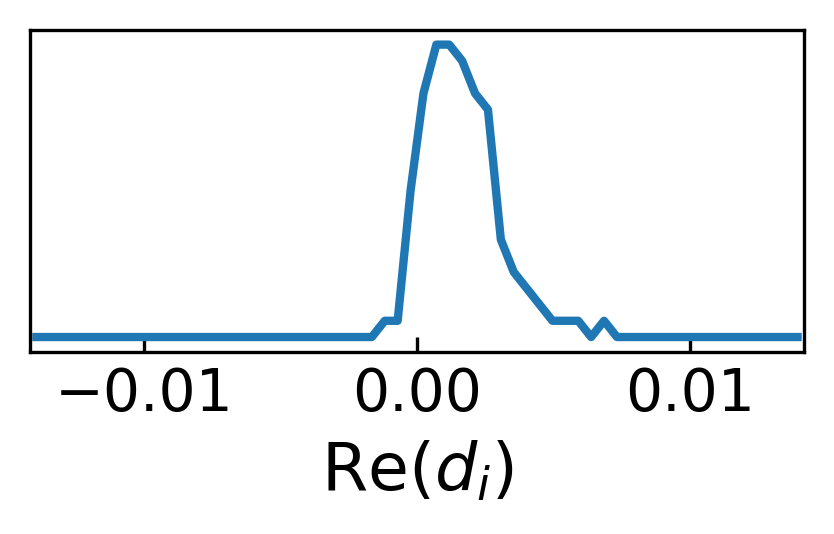

In [81]:
# 1. 计算每个 bin 的中心点坐标
# xedges 和 yedges 是边缘，中心点数量比边缘少 1
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2

# 2. 找到 y_centers 中最接近 0 的索引
# argmin() 会返回绝对值最小处的索引
zero_im_idx = np.abs(y_centers - 0).argmin()

# 3. 从矩阵 H 中提取截面数据
# H 的形状通常是 (nx, ny)，即 (re_bins, im_bins)
# 所以我们需要固定第二个维度 (im)，取所有的第一个维度 (re)
# 注意：np.histogram2d 返回的是 H[x, y]，不用转置直接取列即可
slice_curve = H[:, zero_im_idx]

# 4. 绘制截面图
plt.figure(figsize=(3,2), dpi=300)
plt.plot(x_centers, slice_curve, label=r'Im $\approx$ 0')
plt.xlabel(r"Re$(d_i)$")
# plt.ylabel("Count")
plt.yticks([])
plt.xlim(-max_abs, max_abs)
plt.tight_layout()
plt.show()